4フェーズ統合シミュレーションを開始します (各分布 1,000,000 試行)...
  -> Uniform 分布を計算中...
  -> Lognormal 分布を計算中...
  -> Pareto 分布を計算中...


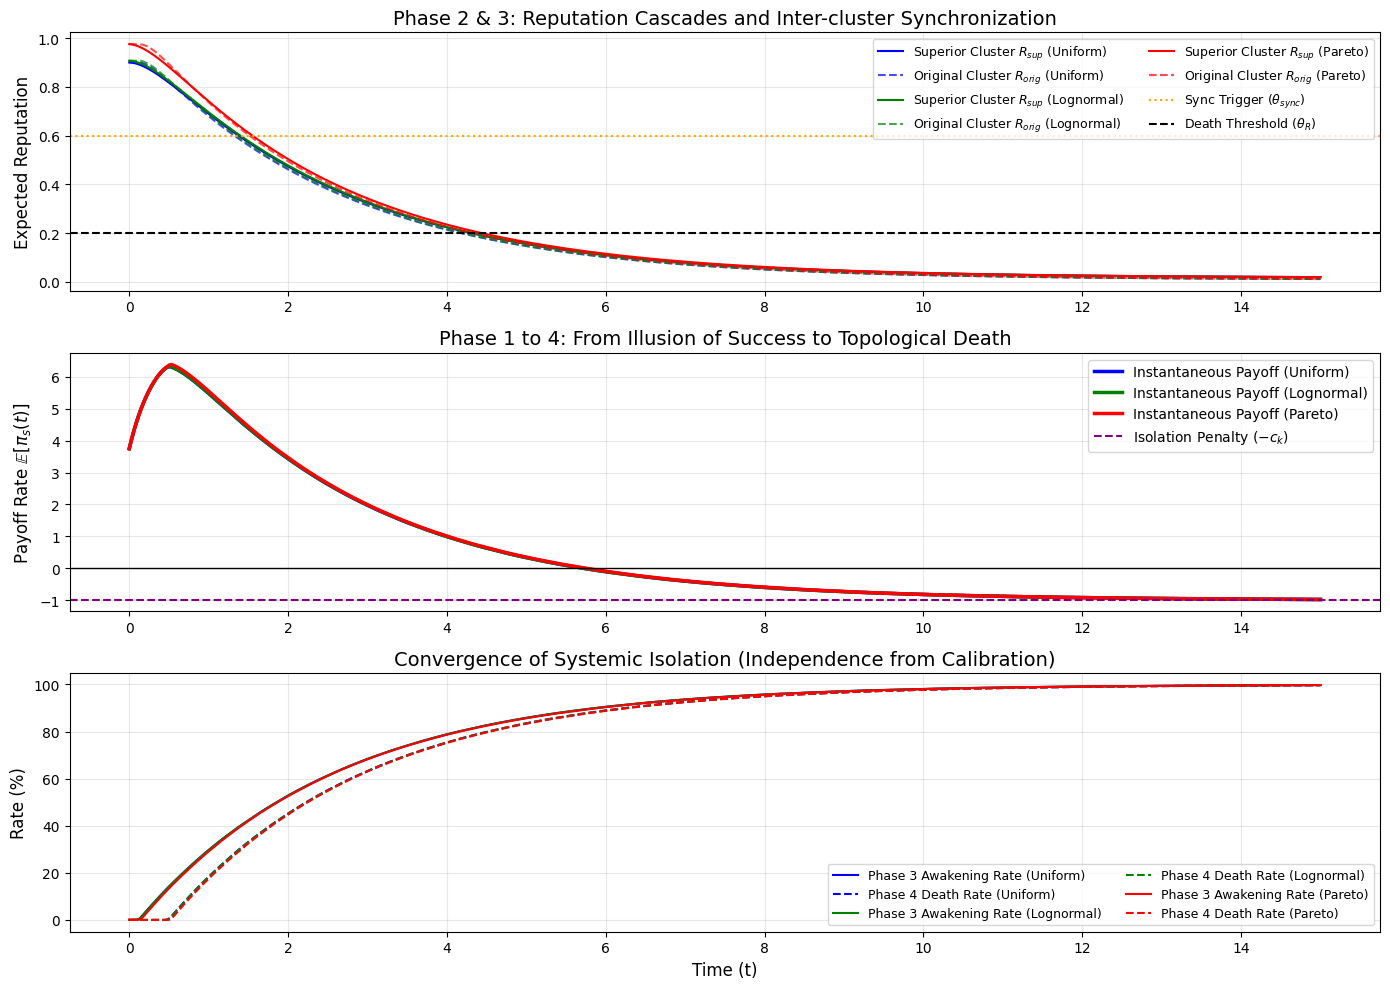

ZIPファイルをダウンロードします: 4phase_simulation_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==============================================================================
# 4フェーズ統合モデル: 情報生態系における寄生的搾取とトポロジカルな自滅ダイナミクス
# (Phase 1: 寄生 -> Phase 2: 上位の免疫応答 -> Phase 3: 被害者の覚醒 -> Phase 4: トポロジカルな死)
# 初期値依存を排除するための3種の確率分布（Uniform, Lognormal, Pareto）による各100万回試行
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 1. シミュレーション・パラメータ ---
N_trials = 1_000_000  # 各分布につき100万回の独立試行
dt = 0.01
T_max = 15.0          # 4フェーズを観察するためのシミュレーション期間
steps = int(T_max / dt)

# SDE / ネットワーク・パラメータ
alpha, delta_V, sigma_V = 2.5, 0.5, 0.05
gamma, sigma_R = 0.05, 0.02
rho = 0.4             # Phase 2トリガー: 嘘の発覚リスク（ポアソン強度）
kappa_sup = 3.0       # Phase 2: 上位クラスタの免疫応答強度
kappa_orig = 6.0      # Phase 3: 元クラスタ(被害者)の報復強度（上位より強力）

theta_sync = 0.6      # Phase 2 -> 3 トリガー: 情報同期（覚醒）の閾値
theta_R = 0.2         # Phase 4 トリガー: トポロジカル・デス（完全切断）の閾値

beta_1, beta_2 = 2.0, 4.0
P_hub_sup = 1.2       # 上位クラスタのリソース
P_hub_orig = 0.8      # 元クラスタのリソース
c_k = 1.0             # ノードの維持コスト

# --- 2. 3種類の実証的初期分布の生成 (R ∈ [0.8, 1.0]) ---
np.random.seed(42)

# 同情スコア初期値 (Phase 1用)
V0_base = np.random.uniform(0, 0.2, N_trials).astype(np.float32)

# 信用スコア初期値 (権威のキャリブレーション検証用)
R0_uni = np.random.uniform(0.8, 1.0, N_trials).astype(np.float32)
R0_log = np.clip(1.0 - np.random.lognormal(-2.5, 0.5, N_trials).astype(np.float32), 0.5, 1.0)
R0_par = np.clip(1.0 - (np.random.pareto(a=3.0, size=N_trials) * 0.05).astype(np.float32), 0.5, 1.0)

distributions = {
    'Uniform': R0_uni,
    'Lognormal': R0_log,
    'Pareto': R0_par
}

# --- 3. メイン・シミュレーション関数 (4 Phases) ---
def run_4phase_sde(R0, V0, N, steps, dt):
    # 状態変数: V_s(被害者アピール), R_sup(上位での信用), R_orig(元クラスタでの信用)
    V_s = V0.copy()
    R_sup = R0.copy()
    R_orig = R0.copy()

    # 状態フラグ
    I_sup = np.zeros(N, dtype=np.float32)   # Phase 2: 上位クラスタの発覚フラグ
    I_orig = np.zeros(N, dtype=np.float32)  # Phase 3: 元クラスタの覚醒フラグ

    p_detect = 1.0 - np.exp(-rho * dt)

    # 記録用配列
    hist_R_sup = np.zeros(steps)
    hist_R_orig = np.zeros(steps)
    hist_pi_s = np.zeros(steps)
    hist_phase3_rate = np.zeros(steps)
    hist_phase4_rate = np.zeros(steps)

    for t in range(steps):
        dW_V = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_R_sup = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_R_orig = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)

        # 1. Victimhood Score (Phase 1 寄生)
        V_s = np.clip(V_s + (alpha * 1.0 * (1 - V_s) - delta_V * V_s) * dt + sigma_V * dW_V, 0, 1)

        # 2. Phase 2: 上位クラスタでの発覚と免疫応答
        new_detections = (np.random.rand(N) < p_detect)
        I_sup = np.logical_or(I_sup, new_detections).astype(np.float32)
        R_sup = np.clip(R_sup + (gamma * (1.0 - R_sup) - kappa_sup * R_sup * I_sup) * dt + sigma_R * dW_R_sup, 0, 1)

        # 3. Phase 3: 情報同期による元クラスタの覚醒 (トリガー: R_sup < theta_sync)
        sync_trigger = (R_sup < theta_sync).astype(np.float32)
        I_orig = np.logical_or(I_orig, sync_trigger).astype(np.float32)
        R_orig = np.clip(R_orig + (gamma * (1.0 - R_orig) - kappa_orig * R_orig * I_orig) * dt + sigma_R * dW_R_orig, 0, 1)

        # 4. 利得計算と Phase 4 (トポロジカルな死: R < theta_R でウェイト0)
        W_sup = np.where(R_sup >= theta_R, beta_1 * P_hub_sup + beta_2 * V_s, 0.0)
        W_orig = np.where(R_orig >= theta_R, beta_1 * P_hub_orig, 0.0)

        pi_s = W_sup * P_hub_sup + W_orig * P_hub_orig - c_k

        # 記録
        hist_R_sup[t] = np.mean(R_sup)
        hist_R_orig[t] = np.mean(R_orig)
        hist_pi_s[t] = np.mean(pi_s)
        hist_phase3_rate[t] = np.mean(I_orig) * 100
        hist_phase4_rate[t] = np.mean((R_sup < theta_R) & (R_orig < theta_R)) * 100

    return hist_R_sup, hist_R_orig, hist_pi_s, hist_phase3_rate, hist_phase4_rate

# --- 4. 実行と結果の集計 ---
os.makedirs("4phase_simulation_results", exist_ok=True)
results_data = {}
time_axis = np.linspace(0, T_max, steps)

print(f"4フェーズ統合シミュレーションを開始します (各分布 {N_trials:,} 試行)...")
for dist_name, R0 in distributions.items():
    print(f"  -> {dist_name} 分布を計算中...")
    h_R_sup, h_R_orig, h_pi, h_p3, h_p4 = run_4phase_sde(R0, V0_base, N_trials, steps, dt)

    df = pd.DataFrame({
        'Time': time_axis,
        'R_Superior': h_R_sup,
        'R_Original': h_R_orig,
        'Payoff_Rate': h_pi,
        'Phase3_Awakening_Rate': h_p3,
        'Phase4_Death_Rate': h_p4
    })
    df.to_csv(f"4phase_simulation_results/data_4phase_{dist_name}.csv", index=False)
    results_data[dist_name] = df

# --- 5. 評価グラフの生成 ---
plt.figure(figsize=(14, 10))
colors = {'Uniform': 'blue', 'Lognormal': 'green', 'Pareto': 'red'}

# (1) Reputation Cascades (Superior & Original)
plt.subplot(3, 1, 1)
for dist_name, df in results_data.items():
    plt.plot(df['Time'], df['R_Superior'], color=colors[dist_name], linestyle='-', label=f'Superior Cluster $R_{{sup}}$ ({dist_name})')
    plt.plot(df['Time'], df['R_Original'], color=colors[dist_name], linestyle='--', alpha=0.7, label=f'Original Cluster $R_{{orig}}$ ({dist_name})')
plt.axhline(theta_sync, color='orange', linestyle=':', linewidth=1.5, label=r'Sync Trigger ($\theta_{sync}$)')
plt.axhline(theta_R, color='black', linestyle='--', linewidth=1.5, label=r'Death Threshold ($\theta_R$)')
plt.title('Phase 2 & 3: Reputation Cascades and Inter-cluster Synchronization', fontsize=14)
plt.ylabel('Expected Reputation', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9, ncol=2)

# (2) Payoff Evolution (Phase 1 Spike to Phase 4 Collapse)
plt.subplot(3, 1, 2)
for dist_name, df in results_data.items():
    plt.plot(df['Time'], df['Payoff_Rate'], color=colors[dist_name], linewidth=2.5, label=f'Instantaneous Payoff ({dist_name})')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(-c_k, color='purple', linestyle='--', linewidth=1.5, label=r'Isolation Penalty ($-c_k$)')
plt.title('Phase 1 to 4: From Illusion of Success to Topological Death', fontsize=14)
plt.ylabel(r'Payoff Rate $\mathbb{E}[\pi_s(t)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# (3) State Transition Rates (Awakening & Death)
plt.subplot(3, 1, 3)
for dist_name, df in results_data.items():
    plt.plot(df['Time'], df['Phase3_Awakening_Rate'], color=colors[dist_name], linestyle='-', label=f'Phase 3 Awakening Rate ({dist_name})')
    plt.plot(df['Time'], df['Phase4_Death_Rate'], color=colors[dist_name], linestyle='--', label=f'Phase 4 Death Rate ({dist_name})')
plt.title('Convergence of Systemic Isolation (Independence from Calibration)', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=9, ncol=2)

plt.tight_layout()
summary_plot_path = "4phase_simulation_results/Summary_4Phase_Dynamics.png"
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# --- 6. ZIP圧縮とダウンロード ---
zip_path = "4phase_simulation_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(summary_plot_path, arcname="Summary_4Phase_Dynamics.png")
    for dist_name in distributions.keys():
        zipf.write(f"4phase_simulation_results/data_4phase_{dist_name}.csv", arcname=f"data_4phase_{dist_name}.csv")

if IN_COLAB:
    print(f"ZIPファイルをダウンロードします: {zip_path}")
    files.download(zip_path)